In [1]:
# con data de ejemplo:
# !gdown 1CWm7PLcGtWTY9vTN05SKtjiW5379-oHz
# con data elaborada por el aula:
!gdown 1i_-_kFy-9u9-Ob2Z7_TIV7TiOZ8gwo0c
# ---> descomprimir
!unzip Imagenes.zip

Downloading...
From (original): https://drive.google.com/uc?id=1i_-_kFy-9u9-Ob2Z7_TIV7TiOZ8gwo0c
From (redirected): https://drive.google.com/uc?id=1i_-_kFy-9u9-Ob2Z7_TIV7TiOZ8gwo0c&confirm=t&uuid=935ff4d4-68fe-4bbc-bc72-490ec4afbdb1
To: /content/Imagenes.zip
100% 30.8M/30.8M [00:00<00:00, 76.4MB/s]
Archive:  Imagenes.zip
  inflating: Imagenes/20191123_093200.jpg  
  inflating: Imagenes/Aviones.jpg    
  inflating: Imagenes/bird.png       
  inflating: Imagenes/cameraman.tif  
  inflating: Imagenes/centro1.jpg    
  inflating: Imagenes/centro2.png    
  inflating: Imagenes/claro.png      
  inflating: Imagenes/contrast1.jpg  
  inflating: Imagenes/contrast2.jpeg  
  inflating: Imagenes/contrast3.jpg  
  inflating: Imagenes/diagonalbars.png  
  inflating: Imagenes/digits.png     
  inflating: Imagenes/DSC_4141.JPG   
  inflating: Imagenes/DSC_4142.JPG   
  inflating: Imagenes/DSC_4143.JPG   
  inflating: Imagenes/DSC_4144.JPG   
  inflating: Imagenes/DSC_4145.JPG   
  inflating: Imagenes

In [1]:
#revisar
import gdown
import zipfile

# Descargar archivo desde Google Drive
file_id = "1i_-_kFy-9u9-Ob2Z7_TIV7TiOZ8gwo0c"
url = f"https://drive.google.com/uc?id={file_id}"

output = "Imagenes.zip"
gdown.download(url, output, quiet=False)

# Descomprimir
with zipfile.ZipFile("Imagenes.zip", 'r') as zip_ref:
    zip_ref.extractall()

Downloading...
From (original): https://drive.google.com/uc?id=1i_-_kFy-9u9-Ob2Z7_TIV7TiOZ8gwo0c
From (redirected): https://drive.google.com/uc?id=1i_-_kFy-9u9-Ob2Z7_TIV7TiOZ8gwo0c&confirm=t&uuid=4b4d1f2a-7878-4a24-ab31-697ddaaecd5f
To: d:\Programacion_Grafica\SEMANA 3\Imagenes.zip
100%|██████████| 30.8M/30.8M [00:03<00:00, 7.99MB/s]


In [2]:
import os, os.path
file_list = os.listdir("Imagenes/")
print(file_list)

['20191123_093200.jpg', 'Aviones.jpg', 'bird.png', 'cameraman.tif', 'centro1.jpg', 'centro2.png', 'claro.png', 'contrast1.jpg', 'contrast2.jpeg', 'contrast3.jpg', 'diagonalbars.png', 'digits.png', 'DSC_4141.JPG', 'DSC_4142.JPG', 'DSC_4143.JPG', 'DSC_4144.JPG', 'DSC_4145.JPG', 'DSC_4146.JPG', 'DSC_4147.JPG', 'eight.tif', 'filter.png', 'horizontalbars.png', 'ipad-min.jpeg', 'lima1.png', 'lima2.png', 'lorito.jpg', 'mamografias', 'MarteC.jpeg', 'mdb97.png', 'moon.jpg', 'noise1.jpg', 'original.gif', 'oscuro.png', 'pathology_cll20x01.jpg', 'pathology_cll40x03.jpg', 'pinguin.jpg', 'placa.jpg', 'rice.png', 'sine.jpg', 'sine2.jpg', 'sine3.jpg', 'skull.png', 'xray.png']


In [3]:
import numpy as np   # <--- n-dim
import cv2           # <--- histograma
import os, os.path   # <--- acceder a los archivos

imageDir = "Imagenes/"
image_set = []

#Creamos una lista con las extensiones aceptadas en la aplicacion
# <---- windows jpg
# <---- otros   jpeg
valid_image_extensions = [".jpg", ".jpeg"]
# convetir en minúsculas
valid_image_extensions = [item.lower() for item in valid_image_extensions]

# obtener todos los archivos en /Imagenes.
file_list = os.listdir(imageDir)

#Recorremos cada archivo y lo incluimos si cumple con la extension
for file in file_list:
    extension = os.path.splitext(file)[1]
    if extension.lower() not in valid_image_extensions:
        continue
    image_set.append(os.path.join(imageDir, file))

# image_set -> guarda los nombres de cada imagen

#Creamos un diccionario
dict = {}
# imagen -> histograma comprimido en 1D

#Para cada imagen, la leemos, calculamos el histograma, lo aplanamos y normalizamos
#El histograma se guarda en un diccionario
for imageName in image_set:

    #para que se lea a blanco y negro:
    #image = cv2.imread(imageName,0)
    #para que se lea a color:
    image = cv2.imread(imageName) #OpenCV lee en formato BGR (azul, verde y rojo)
    image = cv2.cvtColor(image,cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([image], [0,1], None, [8,8], [0, 128, 0 , 256]) #tamaño del hist: 8^3 = 512
    #en blanco y negro:
    #hist = cv2.calcHist([image], [0], None, [8], [0, 256])
    # aplanar el histograma a 1D
    desc = hist.flatten()
    # descriptor -> histograma 1D
    desc = desc/(image.shape[0] * image.shape[1])
    dict[imageName] = desc



In [4]:
dict

{'Imagenes/20191123_093200.jpg': array([5.4038689e-03, 8.3173089e-02, 1.7742026e-01, 8.1076965e-02,
        6.0364839e-02, 9.4229020e-02, 1.8752629e-02, 3.7409954e-03,
        1.5414364e-04, 2.2605124e-04, 2.4498664e-04, 2.3786632e-05,
        3.1298200e-06, 2.4256105e-06, 2.7385925e-06, 1.4084189e-06,
        1.6588046e-05, 4.6947298e-07, 1.5649100e-07, 0.0000000e+00,
        7.8245499e-08, 0.0000000e+00, 1.5649100e-07, 7.8245499e-08,
        2.5977506e-05, 8.6070048e-07, 4.6947298e-07, 1.5649100e-07,
        0.0000000e+00, 7.8245499e-08, 0.0000000e+00, 3.1298200e-07,
        2.1462741e-04, 1.0015424e-05, 1.4084189e-06, 7.8245499e-08,
        0.0000000e+00, 7.8245499e-08, 0.0000000e+00, 7.8245499e-08,
        9.0559777e-03, 1.1798874e-02, 7.8503549e-02, 2.7620661e-05,
        3.6775384e-06, 1.4084189e-06, 5.4771851e-07, 3.1298200e-07,
        5.9096478e-03, 1.0578791e-04, 4.9685892e-05, 1.4866645e-05,
        6.1031487e-06, 4.3035025e-06, 1.3301735e-06, 7.0420947e-07,
        1.345118

In [5]:
print(image_set)

['Imagenes/20191123_093200.jpg', 'Imagenes/Aviones.jpg', 'Imagenes/centro1.jpg', 'Imagenes/contrast1.jpg', 'Imagenes/contrast2.jpeg', 'Imagenes/contrast3.jpg', 'Imagenes/DSC_4141.JPG', 'Imagenes/DSC_4142.JPG', 'Imagenes/DSC_4143.JPG', 'Imagenes/DSC_4144.JPG', 'Imagenes/DSC_4145.JPG', 'Imagenes/DSC_4146.JPG', 'Imagenes/DSC_4147.JPG', 'Imagenes/ipad-min.jpeg', 'Imagenes/lorito.jpg', 'Imagenes/MarteC.jpeg', 'Imagenes/moon.jpg', 'Imagenes/noise1.jpg', 'Imagenes/pathology_cll20x01.jpg', 'Imagenes/pathology_cll40x03.jpg', 'Imagenes/pinguin.jpg', 'Imagenes/placa.jpg', 'Imagenes/sine.jpg', 'Imagenes/sine2.jpg', 'Imagenes/sine3.jpg']


In [6]:
#Hacer busqueda de una imagen aleatoria
import random

#Escogemos un archivo aleatorio
queryName = random.choice(file_list)
# queryName = 'G3_04.jpg'
print(queryName)

#Calculamos el histograma para la imagen seleccionada
queryImage = cv2.imread(os.path.join(imageDir, queryName))
queryImage = cv2.cvtColor(queryImage,cv2.COLOR_BGR2RGB)
queryHist = cv2.calcHist([queryImage],[0,1],None,[8,8],[0,128,0,256])
descQuery = queryHist.flatten()
descQuery = descQuery/(queryImage.shape[0]*queryImage.shape[1])

#Calculamos las distancias a los histogramas almacenados
distances = []

for imageName in image_set:
    # distancia euclidiana de la imagen con respecto a las demás
    dist = np.linalg.norm(descQuery - dict[imageName])
    distances.append(dist)

# Ordenamos por distancias
index = np.argsort(distances)


rice.png


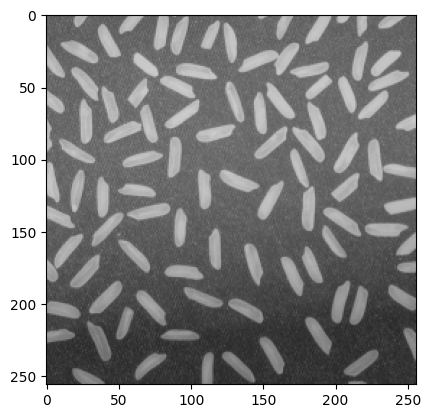

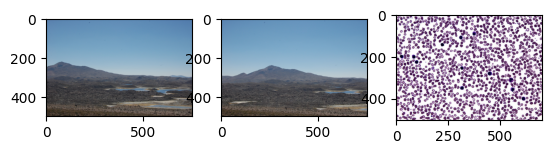

In [7]:
from matplotlib import pyplot as plt

#Seleccionamos los tres menores para visualizar
# fig1 = plt.imshow(queryImage[:,:,::-1])
fig1 = plt.imshow(queryImage, cmap='gray')
#fig1 = plt.imshow(queryImage, cmap='gray')
plt.show()

fig2 = plt.figure()

for i in range(1, 4):
    fig2.add_subplot(1, 3, i)
    imag = cv2.imread(image_set[index[i]])
    plt.imshow(imag[:,:,::-1])

plt.show()


In [9]:



# <--- área verde  -> 20im -> G1
# <--- personas    -> 20im -> G5
# <--- salones     -> 15im -> G4
# <--- mascotas    ->  5im -> G2
# <--- comida      -> 10im -> G3

# jpg

# -> G1_1.jpg G1_2.jpg
# -> G2_2.jpg